<a href="https://colab.research.google.com/github/Sedanuratess/makine-renmesi/blob/main/ArabaFiyatTahmini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

```markdown
## %matplotlib inline Nedir?

`%matplotlib inline` komutu, Jupyter Notebook'lara ve Colab'a özel bir 'sihirli komuttur'. Bu komut, Matplotlib tarafından oluşturulan çizimlerin ayrı bir açılır pencerede değil, doğrudan defter içinde görüntülenmesini sağlar.
```

In [3]:
# warning mesajları için
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [4]:
df=pd.read_csv('/content/Automobile.csv')

In [5]:
df.head(5)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [10]:
df.shape

(205, 26)

In [11]:
len(df)

205

In [12]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [13]:
len(df.columns)

26

In [14]:
# kaç adet numerik sütun var
# price (y) da numerik bir sütun

len(df.describe().columns)

16

In [16]:
for col in df.columns:
  print(col,df[col].nunique())

car_ID 205
symboling 6
CarName 147
fueltype 2
aspiration 2
doornumber 2
carbody 5
drivewheel 3
enginelocation 2
wheelbase 53
carlength 75
carwidth 44
carheight 49
curbweight 171
enginetype 7
cylindernumber 7
enginesize 44
fuelsystem 8
boreratio 38
stroke 37
compressionratio 32
horsepower 59
peakrpm 23
citympg 29
highwaympg 30
price 189


In [17]:
kategorik_sutunlar=df.select_dtypes(include=['object'])
kategorik_sutunlar

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo 144ea,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo 244dl,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo 246,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [19]:
kategorik_sutunlar.nunique()

,0
CarName,147
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
enginetype,7
cylindernumber,7
fuelsystem,8


In [20]:
df.CarName

,CarName
0,alfa-romero giulia
1,alfa-romero stelvio
2,alfa-romero Quadrifoglio
3,audi 100 ls
4,audi 100ls
...,...
200,volvo 145e (sw)
201,volvo 144ea
202,volvo 244dl
203,volvo 246


In [21]:
manufacturer=df['CarName'].apply(lambda x:x.split(' '))
manufacturer

,CarName
0,"[alfa-romero, giulia]"
1,"[alfa-romero, stelvio]"
2,"[alfa-romero, Quadrifoglio]"
3,"[audi, 100, ls]"
4,"[audi, 100ls]"
...,...
200,"[volvo, 145e, (sw)]"
201,"[volvo, 144ea]"
202,"[volvo, 244dl]"
203,"[volvo, 246]"


```markdown
Bu kod bloğu, `CarName` sütunundaki her bir araba isminden üretici adını ayıklamaktadır. `apply(lambda x:x.split(' '))` ifadesi, her bir `CarName` değerini boşluk karakterine göre böler ve bir kelime listesi oluşturur. Bu liste daha sonra `manufacturer` değişkenine atanır. Genellikle, üretici adı `CarName`'in ilk kelimesidir.
```

In [22]:
manufacturer = df['CarName'].apply(lambda x: x.split(' ')[0])
manufacturer

,CarName
0,alfa-romero
1,alfa-romero
2,alfa-romero
3,audi
4,audi
...,...
200,volvo
201,volvo
202,volvo
203,volvo


In [23]:
data=df.copy()

In [24]:
data.head(5)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [25]:
# bu CarName sütununu data'dan çıkaralım
data.drop(columns=['CarName'],axis=1,inplace=True)

In [26]:
data.head(3)

,car_ID,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0


In [27]:
data.insert(3,'manufacturer',manufacturer)

```markdown
Bu kod bloğu, `manufacturer` adında yeni bir sütunu `data` DataFrame'ine belirli bir konuma (`3` numaralı indeks, yani dördüncü sütun) ekler. `insert()` fonksiyonu, bir sütunu DataFrame'in istediğiniz herhangi bir yerine eklemenizi sağlar, `columns` parametresiyle belirttiğimiz sütun ismini ve `value` parametresiyle belirttiğimiz değerleri (bu durumda `manufacturer` Series'ini) kullanarak. Bu işlem, üretici bilgilerini `CarName` sütunu çıkarıldıktan sonra DataFrame'e geri entegre eder.
```

In [28]:
data.head(2)

,car_ID,symboling,fueltype,manufacturer,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0


In [29]:
# hangi üreticinin kaç adet aracı var görelim
data.groupby(by='manufacturer').count()

,car_ID,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
manufacturer,,,,,,,,,,,,,,,,,,,,,
Nissan,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
alfa-romero,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
audi,7,7,7,7,7,7,7,7,7,7,...,7,7,7,7,7,7,7,7,7,7
bmw,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
buick,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
chevrolet,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
dodge,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
honda,13,13,13,13,13,13,13,13,13,13,...,13,13,13,13,13,13,13,13,13,13
isuzu,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4


Üretici adlarında hatalar var
* toyota, toyouta
* mazda, maxda
* Nissan, nissan
* ...

Bunları düzeltelim:

In [30]:
data.manufacturer.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [31]:
#büyük-küçük harf duyarlılığını hallettik
data.manufacturer=data.manufacturer.str.lower()

In [32]:
# hatalı marka adlarını düzeltelim

data.replace({
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'vw',
    'volkswagen': 'vw'
}, inplace=True)

In [33]:
data.manufacturer.unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'vw', 'volvo'], dtype=object)

In [34]:
data.head(2)

,car_ID,symboling,fueltype,manufacturer,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0


# Tekli (Univariate) Analiz Nedir?
Univariate, kelime anlamıyla "tek değişkenli" demektir. Buradaki temel kural şudur: Veri setindeki diğer hiçbir değişkenle ilgilenmezsin. Sadece tek bir sütuna (değişkene) odaklanır, onun kendi içindeki davranışını, dağılımını ve yapısını anlamaya çalışırsın.

Amacımız Nedir? (Bize Ne Fayda Sağlar?)
Tekli analiz yaparken aslında şu soruların cevabını ararsın:

Verinin Tipi Ne? İncelediğin şey kategorik mi (örn: renkler, markalar) yoksa sayısal mı (örn: fiyat, yaş)? Görseldeki symboling sayısal görünse de aslında belirli kategorilerden (-2, -1, 0, 1, 2, 3) oluşuyor. Bu yüzden countplot (frekans grafiği) tercih edilmiş.

Hangi Değerden Kaç Tane Var? Görsele baktığında anında şunu görebiliyorsun: En çok "0" risk derecesine sahip araç var (yaklaşık 67 tane). En az ise "-2" değerine sahip araç var.

Veride Dengizlik (Imbalance) Var mı? Eğer bir gruptan çok fazla, diğerinden neredeyse hiç yoksa bu durum ileride kuracağın makine öğrenmesi modelini yanıltabilir.

Anormallikler (Outliers) veya Hatalar Var mı? Örneğin, risk derecesi sadece -3 ile +3 arasında olması gerekirken grafikte "99" gibi bir sayı görseydin, veri setinde bir hata olduğunu erkenden fark edecektin.

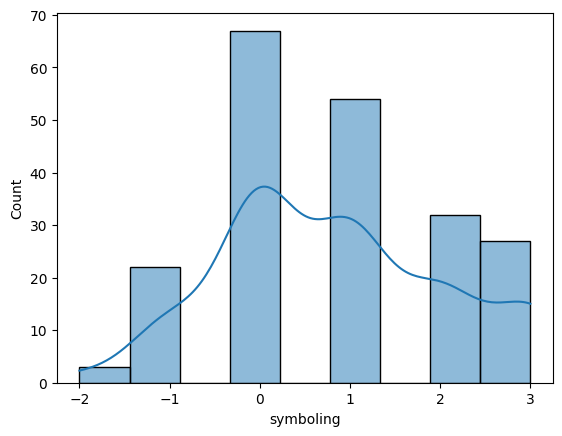

In [37]:
# symboling -> sigorta riski
# Verinin frekans dağılımını (yoğunluğunu) görmek için:
sns.histplot(data=data, x='symboling', kde=True)
plt.show()

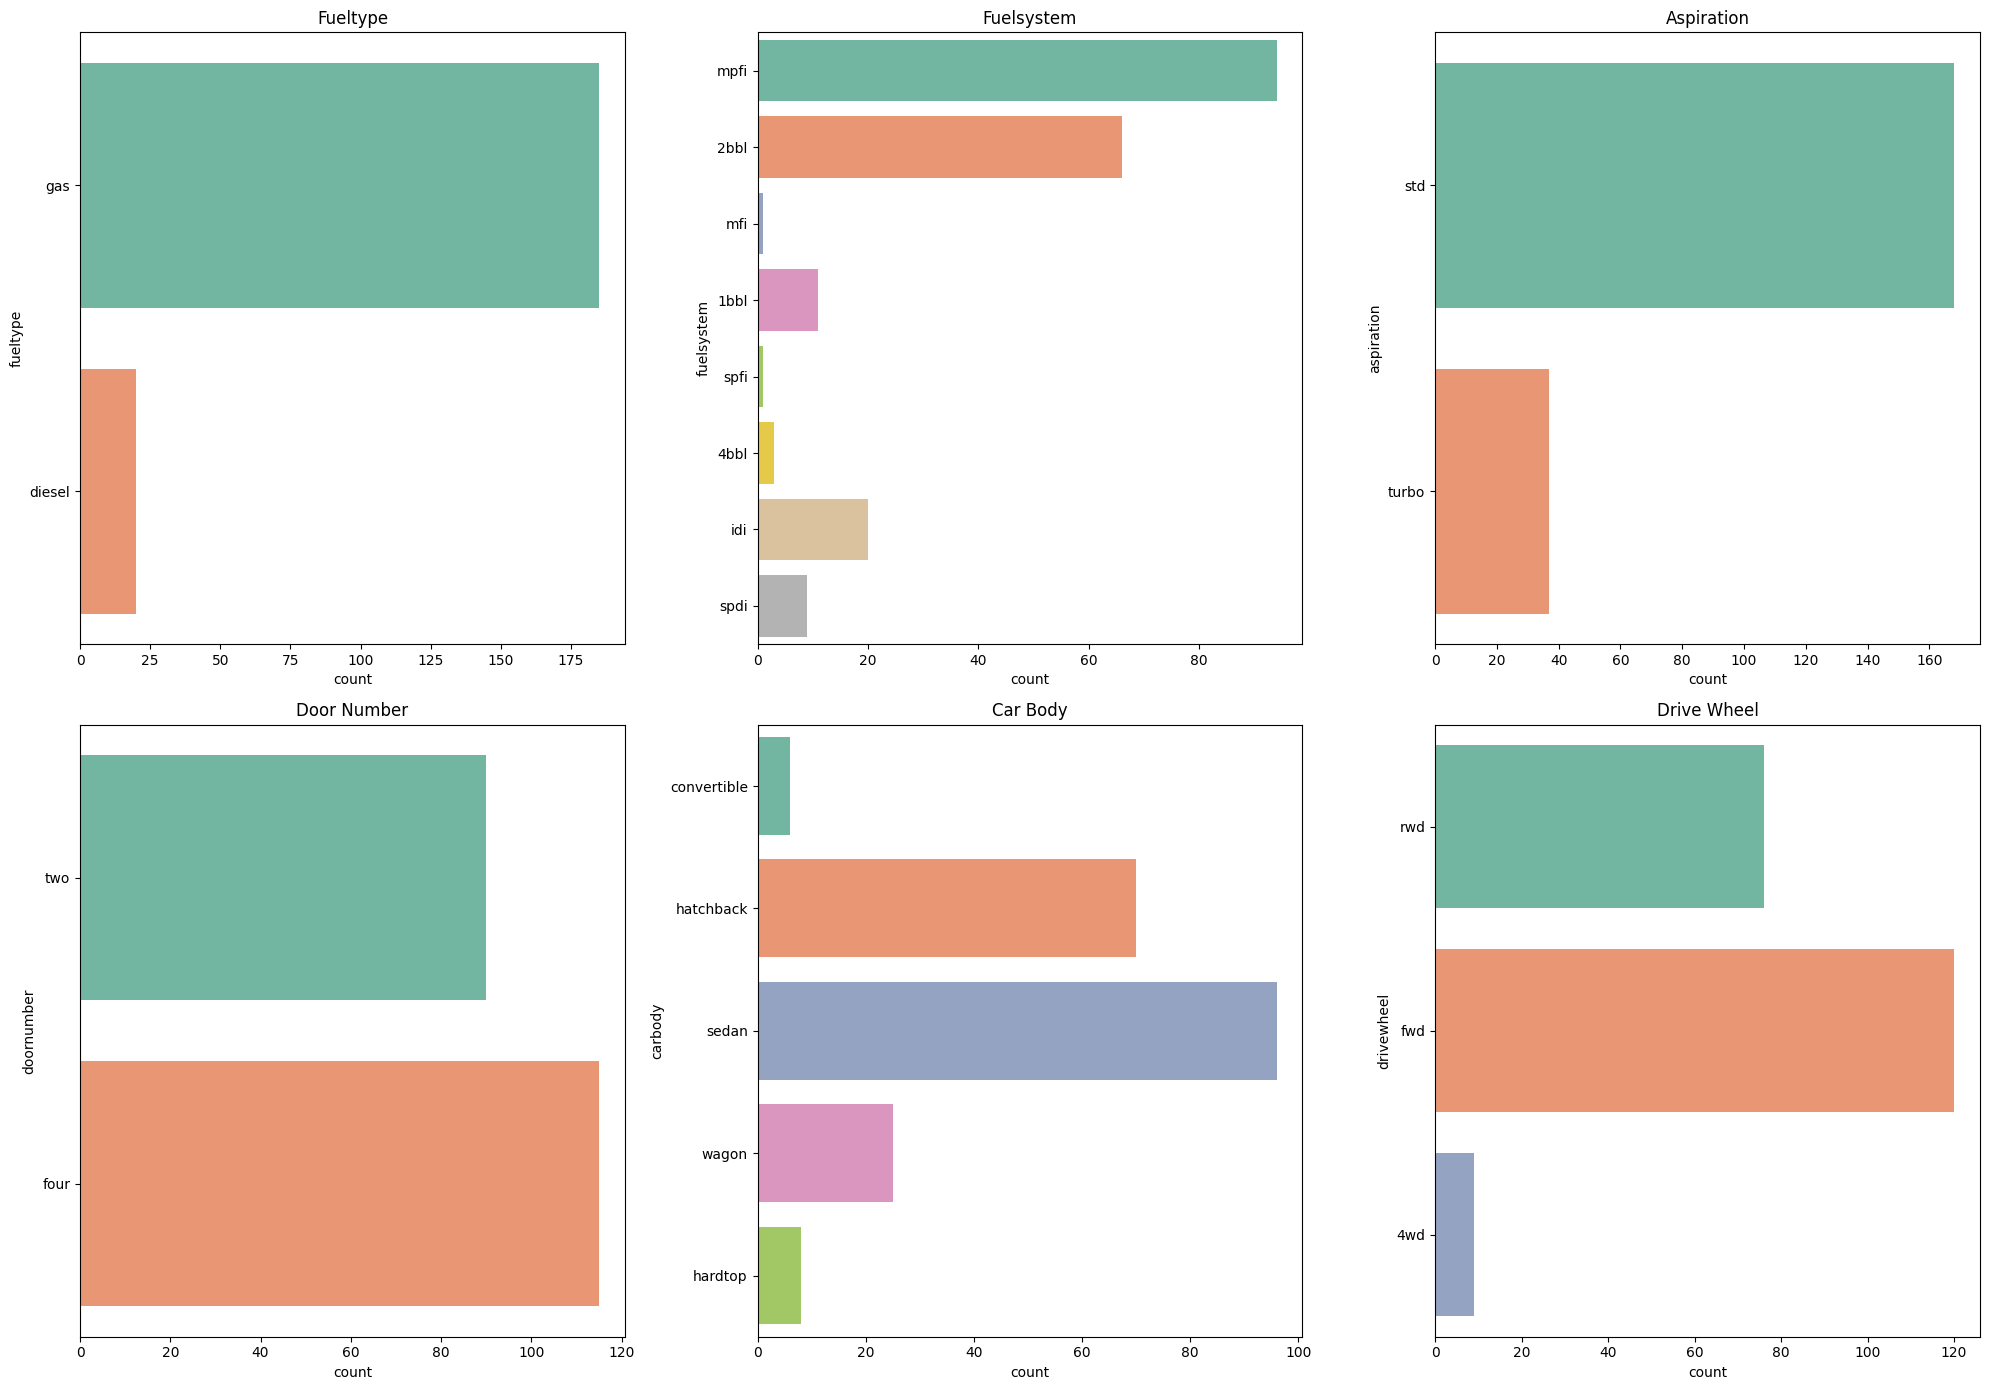

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik alanının boyutunu belirliyoruz
fig = plt.figure(figsize=(20, 14))

# Kullanmak istediğin renk paleti (Örn: 'Set2', 'pastel', 'viridis', 'coolwarm')
renk_paleti = "Set2"

# 1. Fueltype
plt.subplot(2, 3, 1)
plt.title('Fueltype')
# x yerine y yazarak yatay yaptık, hue ve palette ile renklendirdik
sns.countplot(y=data['fueltype'], hue=data['fueltype'], palette=renk_paleti, legend=False)

# 2. Fuelsystem
plt.subplot(2, 3, 2)
plt.title('Fuelsystem')
sns.countplot(y=data['fuelsystem'], hue=data['fuelsystem'], palette=renk_paleti, legend=False)

# 3. Aspiration
plt.subplot(2, 3, 3)
plt.title('Aspiration')
sns.countplot(y=data['aspiration'], hue=data['aspiration'], palette=renk_paleti, legend=False)

# 4. Door Number
plt.subplot(2, 3, 4)
plt.title('Door Number')
sns.countplot(y=data['doornumber'], hue=data['doornumber'], palette=renk_paleti, legend=False)

# 5. Car Body
plt.subplot(2, 3, 5)
plt.title('Car Body')
sns.countplot(y=data['carbody'], hue=data['carbody'], palette=renk_paleti, legend=False)

# 6. Drive Wheel
plt.subplot(2, 3, 6)
plt.title('Drive Wheel')
sns.countplot(y=data['drivewheel'], hue=data['drivewheel'], palette=renk_paleti, legend=False)

# Grafiklerin birbirinin üstüne binmesini engellemek için ideal boşlukları ayarlar
plt.tight_layout()
plt.show()

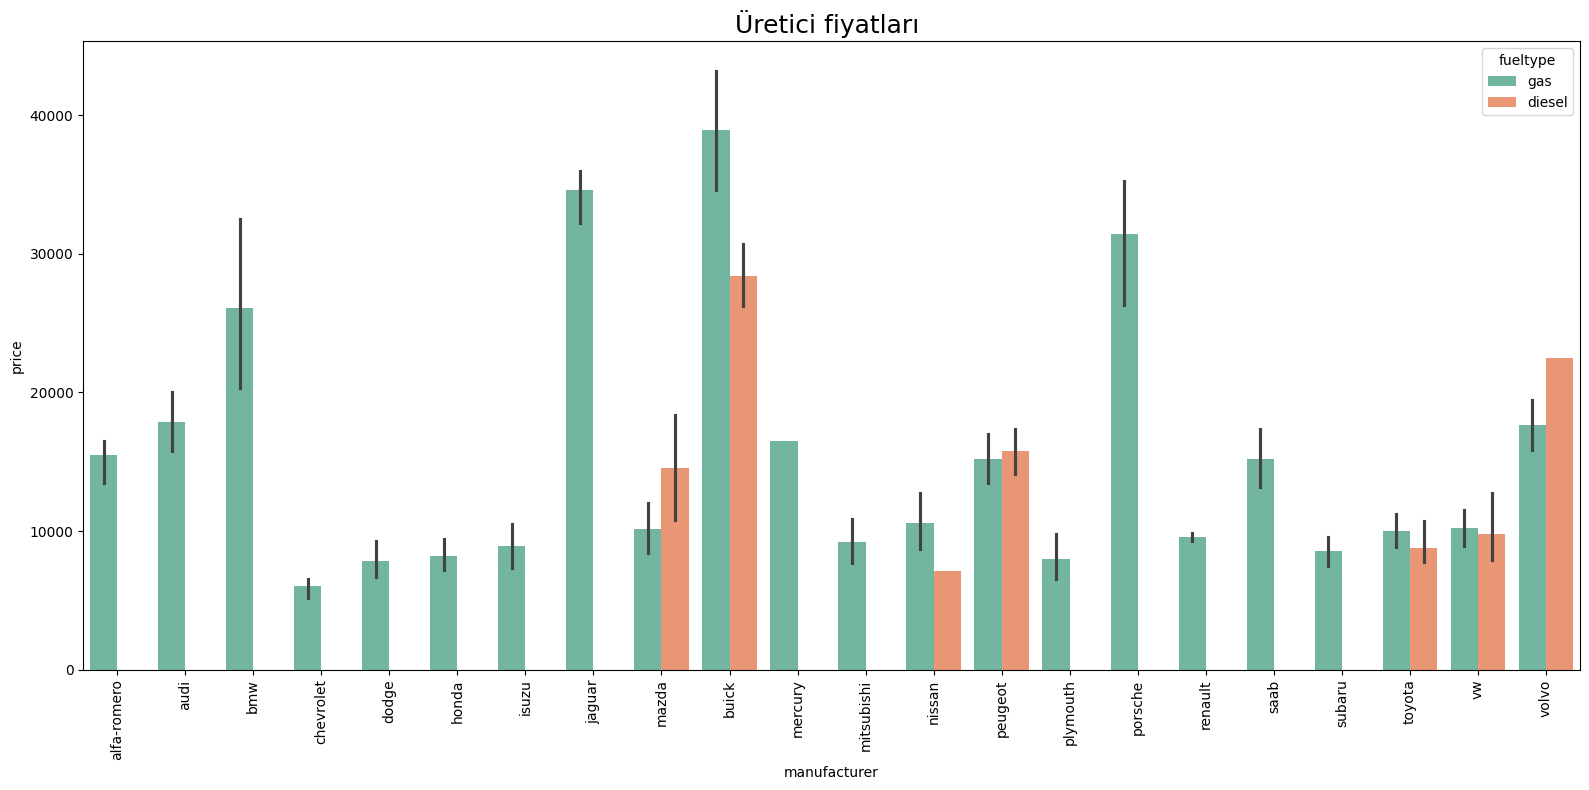

In [40]:
#üretici bazlı ortalama fiyatlar
plt.figure(figsize=(16,8))
plt.title('Üretici fiyatları ',fontsize=18)
sns.barplot(
    x=data.manufacturer,y=data.price,
    hue=data.fueltype,palette='Set2')
plt.xticks(rotation=90)
plt.tight_layout()

```markdown
## 40. Hücredeki Barplot Analizi

Bu hücredeki barplot grafiği, üretici bazında ortalama fiyatları, yakıt türüne göre ayrıştırarak görselleştirmektedir. Kullanılan ana materyaller (parametreler) şunlardır:

*   **`plt.figure(figsize=(16,8))`**: Bu komut, oluşturulacak grafiğin boyutunu belirler. `(16,8)` ifadesi, grafiğin genişliğinin 16 inç, yüksekliğinin ise 8 inç olacağını gösterir. Bu, daha okunaklı ve detaylı bir görsel elde etmek için kullanılır.

*   **`plt.title('Üretici fiyatları ',fontsize=18)`**: Grafiğe bir başlık ekler. Başlık metni 'Üretici fiyatları ' olarak belirlenmiş ve `fontsize=18` ile başlığın yazı boyutu ayarlanmıştır, bu da başlığın daha dikkat çekici olmasını sağlar.

*   **`sns.barplot(...)`**: Seaborn kütüphanesinin çubuk grafik çizme fonksiyonudur. İçinde aşağıdaki parametreleri barındırır:
    *   **`x=data.manufacturer`**: X ekseninde gösterilecek veriyi belirtir. Burada `data` DataFrame'indeki 'manufacturer' (üretici) sütunu kullanılmaktadır. Her bir çubuk bir üreticiyi temsil eder.
    *   **`y=data.price`**: Y ekseninde gösterilecek veriyi belirtir. Burada `data` DataFrame'indeki 'price' (fiyat) sütunu kullanılmaktadır. `barplot` varsayılan olarak bu sütunun ortalamasını (mean) hesaplar ve çubukların yüksekliği bu ortalama fiyatı gösterir.
    *   **`hue=data.fueltype`**: Bu parametre, grafiği 'fueltype' (yakıt türü) sütunundaki benzersiz değerlere göre renklendirerek farklı alt grupları karşılaştırmayı sağlar. Böylece her üretici için benzinli ve dizel araçların ortalama fiyatları ayrı çubuklarla gösterilir.
    *   **`palette='Set2'`**: Grafikteki renklerin hangi paletten seçileceğini belirler. 'Set2', Seaborn'da önceden tanımlanmış bir renk paletidir ve farklı kategorileri ayırmak için görsel olarak hoş ve anlaşılır renkler sunar.

*   **`plt.xticks(rotation=90)`**: X ekseni etiketlerini (yani üretici isimlerini) 90 derece döndürür. Üretici isimleri uzun olabileceği için bu, etiketlerin üst üste binmesini engelleyerek okunabilirliği artırır.

*   **`plt.tight_layout()`**: Bu komut, grafiğin ve etiketlerin, başlığın vb. birbirine karışmamasını ve plot alanına sığmasını sağlamak için düzeni otomatik olarak ayarlar. Böylece grafik daha düzenli ve estetiktir.

Bu kod bloğu sayesinde, hangi üreticinin ortalama olarak daha pahalı veya uygun fiyatlı araçlar sunduğunu ve bu durumun yakıt türüne göre nasıl değiştiğini kolayca görselleştirebiliriz.
```

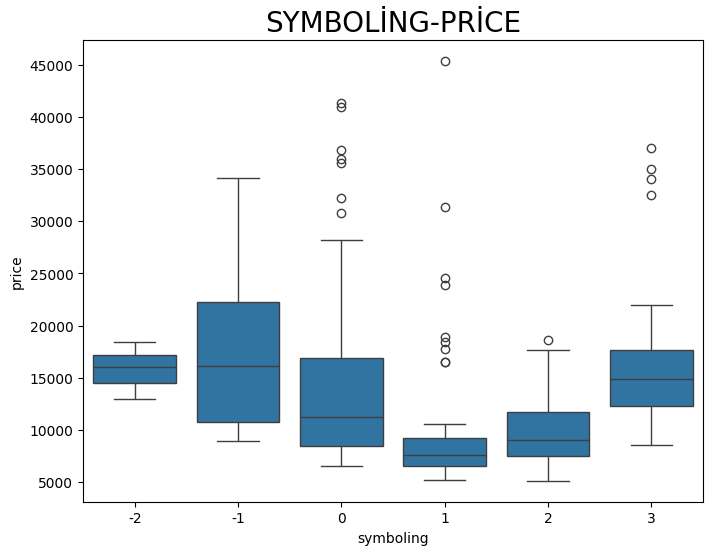

In [47]:
plt.figure(figsize=(8,6))
sns.boxplot(x=data.symboling, y=data.price)
plt.title('SYMBOLİNG-PRİCE',fontsize=20)
plt.show()

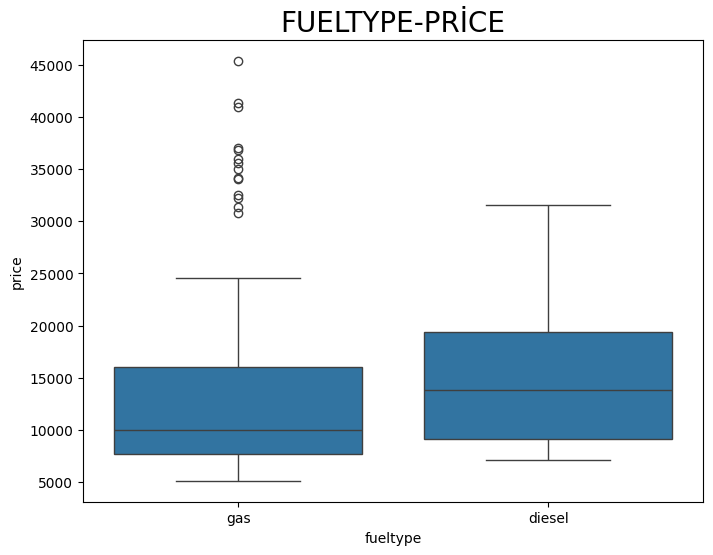

In [46]:

plt.figure(figsize=(8,6))
sns.boxplot(x=data.fueltype, y=data.price)
plt.title('FUELTYPE-PRİCE',fontsize=20)
plt.show()

<Axes: xlabel='enginelocation', ylabel='price'>

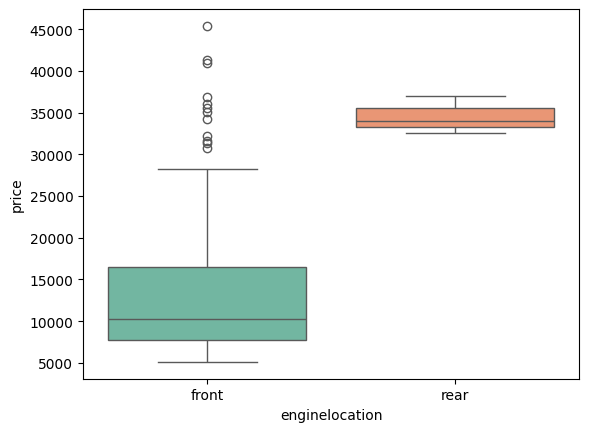

In [56]:
sns.boxplot(x=data.enginelocation,y=data.price,hue=data.enginelocation,palette='Set2',legend=False)

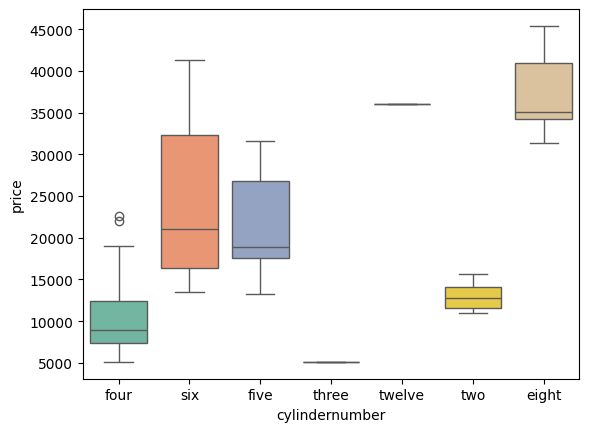

In [55]:
sns.boxplot(x=data.cylindernumber, y=data.price, hue=data.cylindernumber, palette="Set2", legend=False)

plt.show()

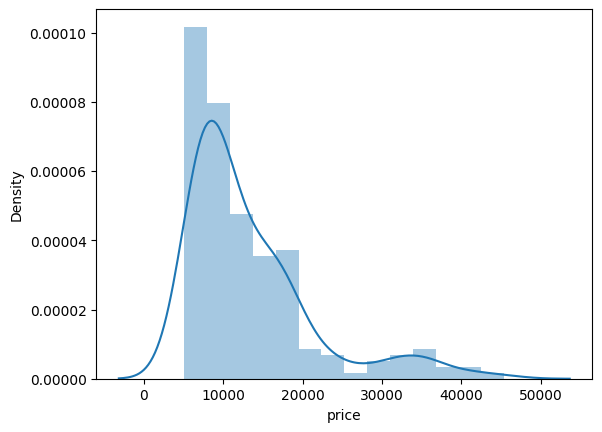

In [57]:
sns.distplot(data.price)
plt.show()

1. Dağılımın Şekli ve Çarpıklık (Skewness)
Sağa Çarpık (Right-Skewed / Positively Skewed) Dağılım: Grafiğin kuyruğu sağ tarafa doğru uzamaktadır. Bu durum bize, veri setindeki araçların çok büyük bir kısmının ucuz/ortalama fiyatlı olduğunu, sadece az sayıda lüks veya özel aracın fiyatının çok yüksek (35.000 - 45.000+ birim) olduğunu gösterir.

2. Yoğunluk ve Kümelenme (Mod)
En Yoğun Bölge (Zirve Noktası): Grafik en yüksek zirvesini 5.000 ile 12.000 birim arasında yapmıştır. Yani bu veri setinden rastgele bir araba seçersek, bu arabanın fiyatının 10.000 civarında olma olasılığı son derece yüksektir. Pazarın kalbi burasıdır.

Fiyat Artışıyla Azalan Yoğunluk: 20.000 birim fiyattan sonra araç sayısı hızla düşmektedir.

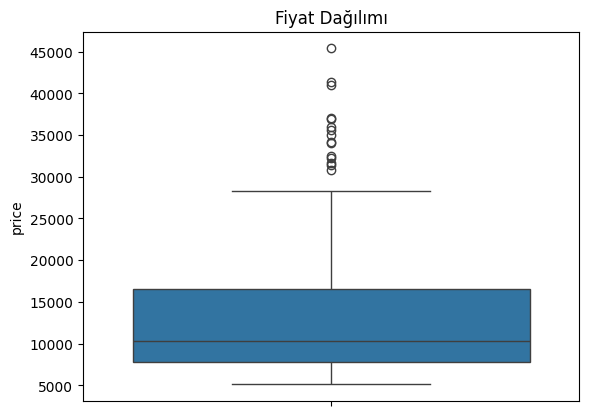

In [58]:

plt.title('Fiyat Dağılımı')
sns.boxplot(y=data.price)
plt.show()

In [59]:
#istatik veriler üzerinden bakalım
data.price.describe()

,price
count,205.000000
mean,13276.710571
std,7988.852332
min,5118.000000
25%,7788.000000
50%,10295.000000
75%,16503.000000
max,45400.000000


In [60]:
data.columns

Index(['car_ID', 'symboling', 'fueltype', 'manufacturer', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [61]:
# sadece şunları alalım

cols = ['wheelbase', 'carlength', 'carwidth', 'carheight',
        'curbweight', 'enginesize', 'boreratio', 'stroke',
        'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

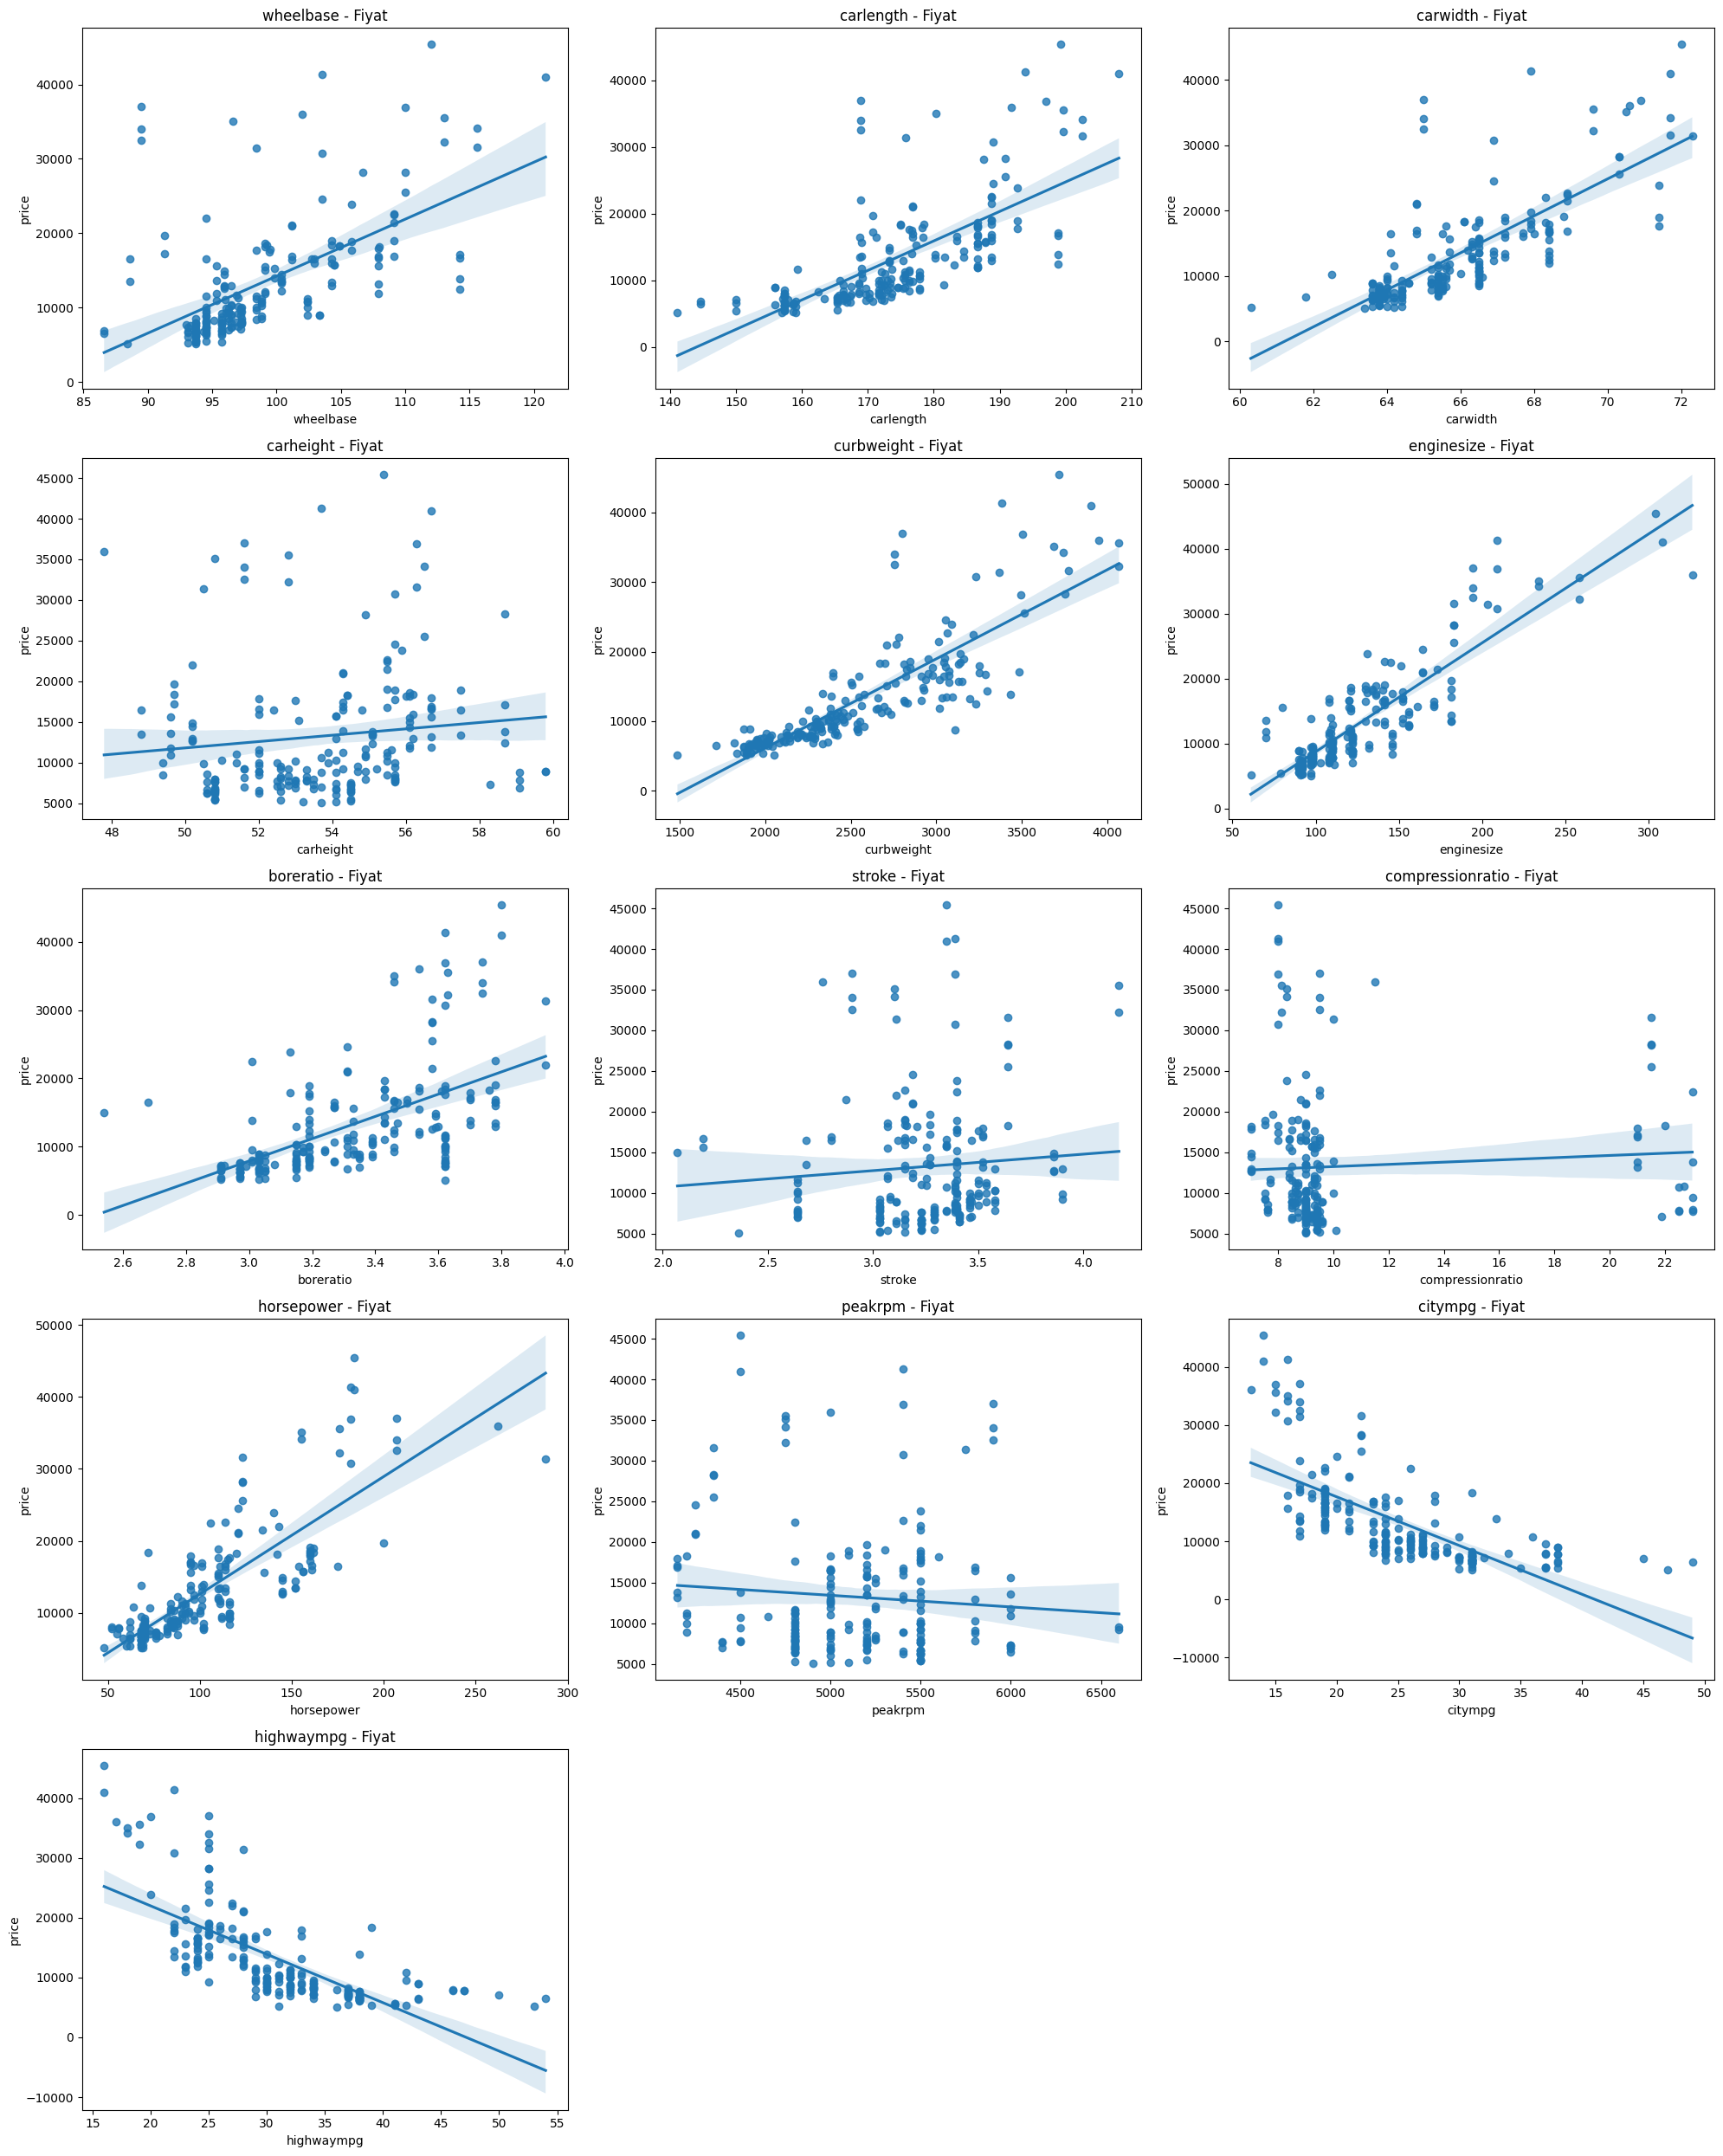

In [62]:
# regresyon doğruları ile ilişkiyi görelim

plt.figure(figsize=(20,25))

for i in range(len(cols)):
    plt.subplot(5,3,i+1)
    plt.title(cols[i] + ' - Fiyat')
    sns.regplot(x=eval('data' + '.' + cols[i]), y=data.price)

plt.tight_layout()

**1. Çizginin Eğimi (En Önemli Kriter)**
Eğilim çizgisinin açısı bize ilişkinin gücünü söyler.

Dik Açılı Çizgiler (Çok Önemli): Çizgi sağa doğru sert bir şekilde yükseliyor veya aşağı iniyorsa o değişken fiyatı doğrudan etkiliyor demektir.

Örnek: enginesize (Motor Hacmi), curbweight (Araç Ağırlığı) ve horsepower (Beygir Gücü) grafiklerine bak. Çizgiler yukarıya doğru çok net ve dik bir açıyla gidiyor. Motor büyüdükçe veya beygir arttıkça fiyat net bir şekilde fırlıyor. Bunlar modelin için en kritik değişkenlerdir.

Ters Yönlü Dik Çizgiler (Çok Önemli): Çizginin aşağı doğru dik inmesi de çok önemlidir (Negatif Korelasyon).

Örnek: citympg ve highwaympg (Yakıt Tüketimi/Mil Değeri). Çizgi aşağı doğru sert iniyor. Yani araç mil başına daha çok yakıyorsa (galon başına mil değeri düştükçe) fiyatı artıyor, ya da tam tersi yakıt tasarruflu ekonomik araçların fiyatı daha düşük kalıyor demektir. Bu da çok önemli bir girdidir.

Düz / Yatay Çizgiler (Önemsiz): Çizgi dümdüz ilerliyorsa, o değişkenin artması veya azalması fiyatı hiç etkilemiyor demektir.

Örnek: compressionratio (Sıkıştırma Oranı), peakrpm ve carheight (Araç Yüksekliği) grafiklerine bak. Çizgiler neredeyse dümdüz, yatay gidiyor. Aracın yüksek olması veya peak rpm değeri fiyatı belirlemede bir rol oynamıyor. Bunlar model için önemsiz/etkisiz değişkenlerdir.

**2. Noktaların Çizgiye Yakınlığı (Güvenilirlik)**
Çizginin etrafındaki noktalar ne kadar sıkı ve çizgiye yakın diziliyorsa, aralarındaki ilişki o kadar kararlı ve tahmin edilebilirdir.

Sıkı Kümelenme (Yüksek Güven): curbweight grafiğine bak. Noktalar çizginin etrafında adeta bir ip gibi dizilmiş, etrafa çok fazla saçılmamış. Bu, ağırlık verisinin fiyatı tahmin etmekte çok kararlı bir yardımcı olacağını gösterir.

Dağınık Yapı (Düşük Güven): stroke veya wheelbase grafiklerine bak. Noktalar bulut gibi her yere yayılmış. Çizgi yukarı doğru hafif bir eğim gösterse bile noktalar çok dağınık olduğu için bu değişkenlerin tek başına fiyata etkisi zayıftır.

Burada nerdeyse tüm değişkenleri önemli. Yani fiyat üzerinde etkisi olabilir.

Etkisiz olanlar:
* carheight
* stroke
* compression ratio
* peak rpm
* highway mpg
* city mpg

Bunları çıkarabiliriz.

In [63]:
data.columns

Index(['car_ID', 'symboling', 'fueltype', 'manufacturer', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [64]:
# yeni sütunlarla yeni data

data_new = data[[
        'car_ID', 'symboling', 'fueltype', 'manufacturer', 'aspiration',
        'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
        'carlength', 'carwidth', 'curbweight', 'enginetype', 'cylindernumber',
        'enginesize', 'fuelsystem', 'boreratio', 'horsepower', 'price']]

In [65]:
data_new.head()

,car_ID,symboling,fueltype,manufacturer,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,horsepower,price
0,1,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,64.1,2548,dohc,four,130,mpfi,3.47,111,13495.0
1,2,3,gas,alfa-romero,std,two,convertible,rwd,front,88.6,168.8,64.1,2548,dohc,four,130,mpfi,3.47,111,16500.0
2,3,1,gas,alfa-romero,std,two,hatchback,rwd,front,94.5,171.2,65.5,2823,ohcv,six,152,mpfi,2.68,154,16500.0
3,4,2,gas,audi,std,four,sedan,fwd,front,99.8,176.6,66.2,2337,ohc,four,109,mpfi,3.19,102,13950.0
4,5,2,gas,audi,std,four,sedan,4wd,front,99.4,176.6,66.4,2824,ohc,five,136,mpfi,3.19,115,17450.0


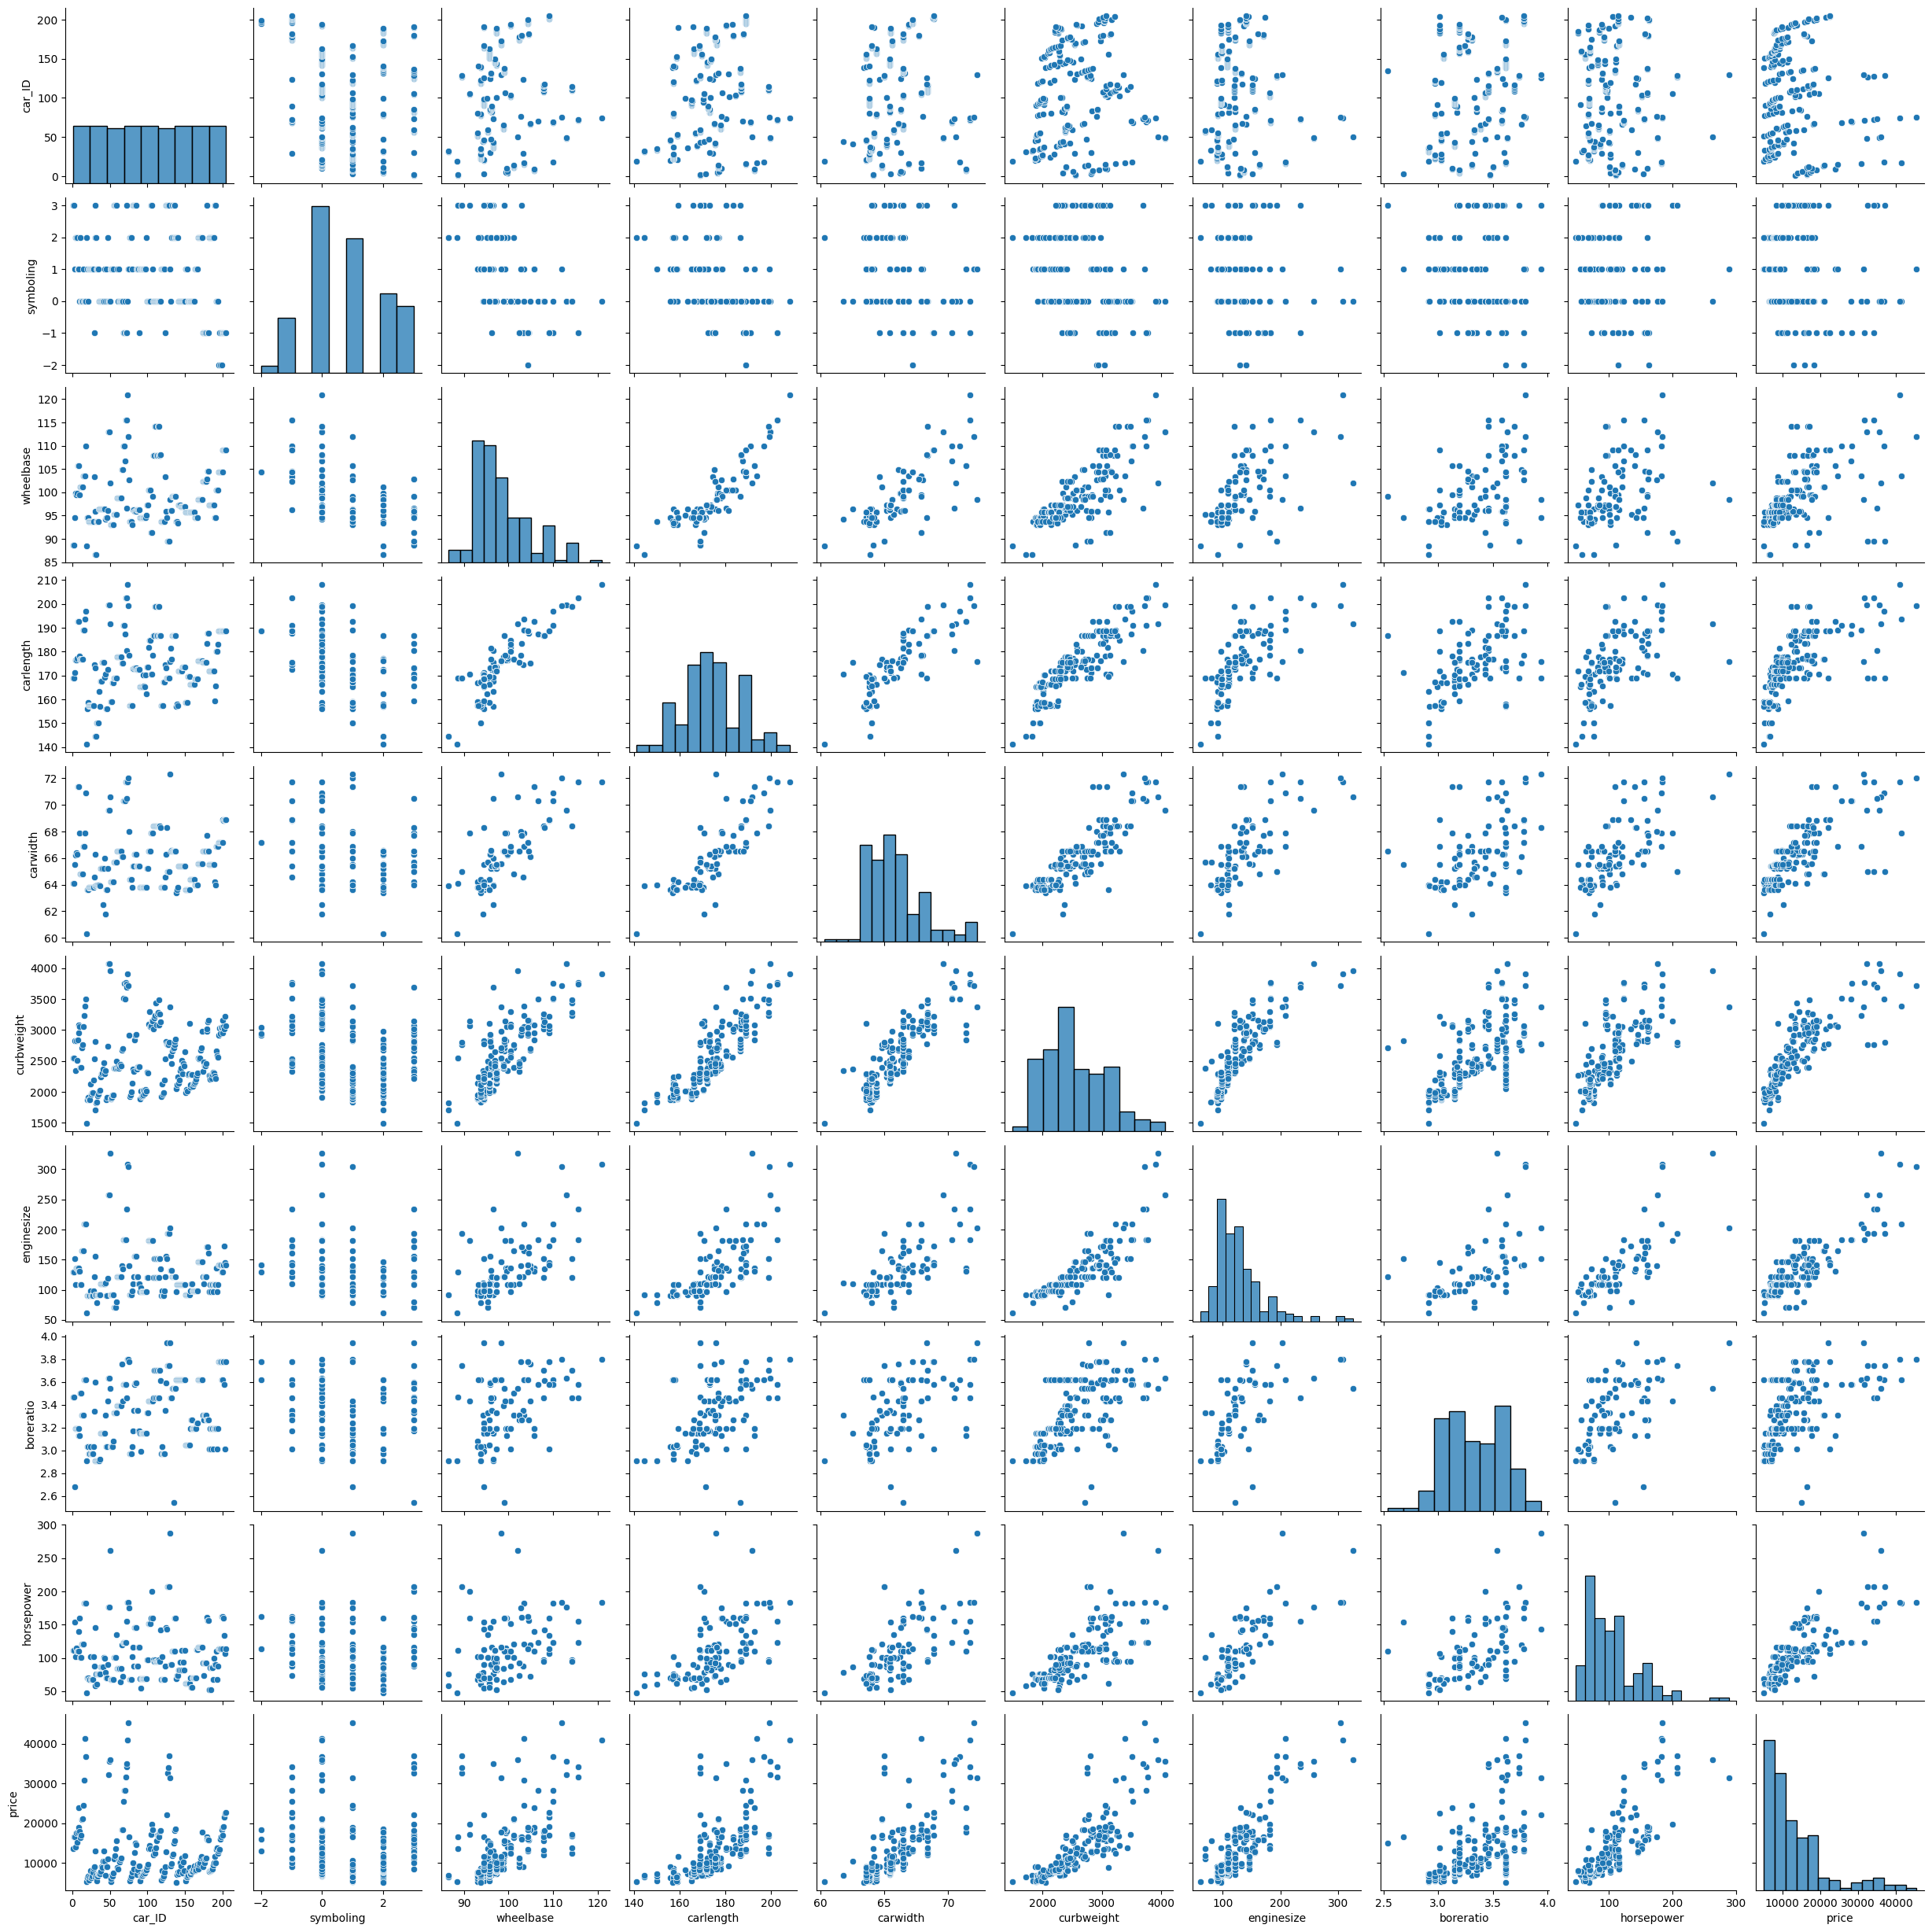

In [66]:
sns.pairplot(data_new)
plt.show()

# FEATURE ENGINEERING
Datayı daha iyi modellemek için yeni özellikler (feature) bulma veya özelliklerden bazılarını eleme işine **Feature Engineering** denir.

In [67]:
#tork aracın çekiş gücüyle  alakalı
torque = data.horsepower * 5252 / data.peakrpm

In [68]:
torque

,0
0,116.594400
1,116.594400
2,161.761600
3,97.400727
4,109.814545
...,...
200,110.875556
201,158.550943
202,127.957818
203,115.981667


In [69]:
# dataya torque sütunu ekle

data.insert(10, 'torque',
            pd.Series(data.horsepower * 5252 / data.peakrpm, index=data.index))

In [70]:
data.torque

,torque
0,116.594400
1,116.594400
2,161.761600
3,97.400727
4,109.814545
...,...
200,110.875556
201,158.550943
202,127.957818
203,115.981667


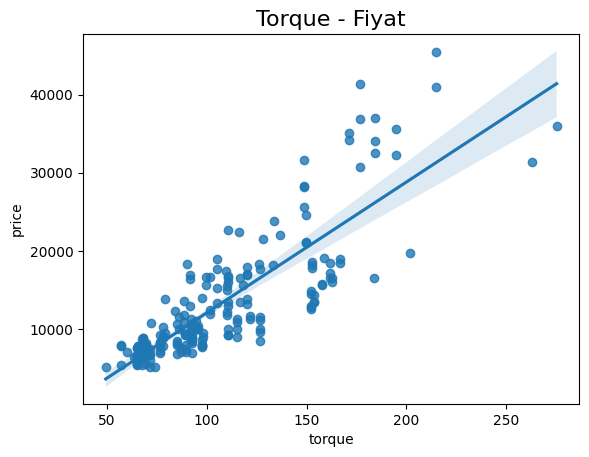

In [71]:
plt.title('Torque - Fiyat', fontsize=16)

sns.regplot(x=data.torque, y=data.price)

plt.show()

```markdown
## `sns.regplot` Nedir?

`sns.regplot` (Regression Plot), Seaborn kütüphanesinin iki değişken arasındaki ilişkiyi görselleştirmek için kullandığı güçlü bir fonksiyondur. Özellikle bir regresyon çizgisi (eğilim çizgisi) ve bu çizginin etrafındaki güven aralığını göstererek, değişkenler arasındaki doğrusal ilişkiyi anlamamıza yardımcı olur.

### Temel Özellikleri:

1.  **Dağılım Grafiği (Scatter Plot)**:
    *   `sns.regplot` öncelikle, belirttiğiniz `x` ve `y` eksenindeki değerlerin her bir çiftini bir nokta olarak gösteren bir dağılım grafiği çizer. Bu, verilerin genel dağılımını ve kümelenmelerini görmemizi sağlar.

2.  **Regresyon Çizgisi (Regression Line)**:
    *   Bu, noktaların genel eğilimini gösteren düz bir çizgidir. Bu çizgi, `x` ve `y` arasındaki doğrusal ilişkinin en iyi temsilini sunar. Genellikle, en küçük kareler yöntemiyle (Ordinary Least Squares - OLS) hesaplanır. Çizginin eğimi, bir değişken değiştiğinde diğer değişkenin ortalama olarak ne kadar değiştiğini gösterir.

3.  **Güven Aralığı (Confidence Interval)**:
    *   Regresyon çizgisinin etrafında bir gölgeli alan bulunur. Bu alan, regresyon çizgisinin gerçek popülasyon regresyon çizgisini %95 (varsayılan) olasılıkla içereceğine dair bir güven aralığıdır. Bu aralık, tahminin ne kadar güvenilir olduğunu gösterir. Alan ne kadar darsa, tahmin o kadar güvenilirdir.

### `sns.regplot` ne zaman kullanılır?

*   İki sayısal değişken arasında doğrusal bir ilişki olup olmadığını merak ettiğinizde.
*   Bu ilişkinin yönünü (pozitif mi, negatif mi) ve gücünü (eğimin dikliği) görsel olarak incelemek istediğinizde.
*   Belirli bir değişkenin diğer bir değişken üzerindeki etkisinin ne kadar tutarlı (güven aralığının darlığı) olduğunu anlamak istediğinizde.

Özetle, `sns.regplot` iki değişken arasındaki ilişkiyi hem noktalarla (gerçek veriler) hem de bir çizgiyle (istatistiksel model) göstererek, verideki eğilimleri hızlıca fark etmemizi sağlayan çok kullanışlı bir görselleştirme aracıdır.
```

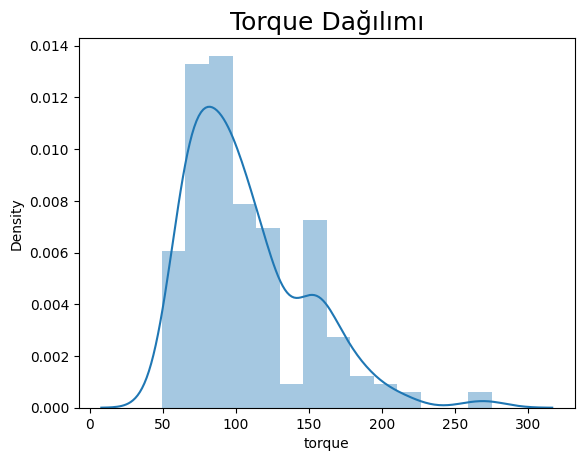

In [72]:
# Torque dağılımını görelim

plt.title('Torque Dağılımı', fontsize=18)
sns.distplot(data.torque)

plt.show()

In [74]:
data['fueleconomy'] = (0.55 * data.citympg) + (0.45 * data.highwaympg)

In [75]:
data.fueleconomy

,fueleconomy
0,23.70
1,23.70
2,22.15
3,26.70
4,19.80
...,...
200,25.25
201,21.70
202,20.25
203,26.45


In [77]:
# silinecekleri sil

data.drop(columns=['car_ID','manufacturer','doornumber','carheight',
                   'compressionratio', 'symboling','stroke','citympg',
                   'highwaympg', 'fuelsystem', 'peakrpm'],
          axis=1, inplace=True)

In [78]:
data.head()

,fueltype,aspiration,carbody,drivewheel,enginelocation,wheelbase,torque,carlength,carwidth,curbweight,enginetype,cylindernumber,enginesize,boreratio,horsepower,price,fueleconomy
0,gas,std,convertible,rwd,front,88.6,116.594400,168.8,64.1,2548,dohc,four,130,3.47,111,13495.0,23.70
1,gas,std,convertible,rwd,front,88.6,116.594400,168.8,64.1,2548,dohc,four,130,3.47,111,16500.0,23.70
2,gas,std,hatchback,rwd,front,94.5,161.761600,171.2,65.5,2823,ohcv,six,152,2.68,154,16500.0,22.15
3,gas,std,sedan,fwd,front,99.8,97.400727,176.6,66.2,2337,ohc,four,109,3.19,102,13950.0,26.70
4,gas,std,sedan,4wd,front,99.4,109.814545,176.6,66.4,2824,ohc,five,136,3.19,115,17450.0,19.80


In [79]:
cars=data.copy()

In [80]:
# kategorik sütunlar

dummies_list = ['fueltype', 'aspiration', 'carbody','drivewheel',
                'enginelocation', 'enginetype', 'cylindernumber']

In [81]:

for i in dummies_list:

    temp_df = pd.get_dummies(eval('cars' + '.' + i), drop_first=True)

    cars = pd.concat([cars, temp_df], axis=1)

    cars.drop([i], axis=1, inplace=True)

```markdown
## 81. Hücredeki İşlem: One-Hot Encoding (Kategorik Değişkenleri Sayısala Çevirme)

Bu kod bloğu, `dummies_list` içinde tanımlanan kategorik sütunları (örn: `fueltype`, `aspiration`, `carbody` vb.) makine öğrenimi modelleri tarafından işlenebilen sayısal formata dönüştürmek için "One-Hot Encoding" adı verilen bir teknik kullanır.

İşte adım adım ne yaptığı:

1.  **`for i in dummies_list:`**: `dummies_list` içindeki her bir kategorik sütun adı (`i`) için bir döngü başlatılır. Bu, her bir kategorik sütunu sırayla işleyeceği anlamına gelir.

2.  **`temp_df = pd.get_dummies(eval('cars' + '.' + i), drop_first=True)`**:
    *   `eval('cars' + '.' + i)`: Bu kısım, `cars` DataFrame'inin mevcut döngüdeki kategorik sütununu (`i`) seçer. Örneğin, ilk döngüde `cars.fueltype` seçilecektir.
    *   `pd.get_dummies(...)`: Pandas'ın bu fonksiyonu, seçilen kategorik sütunu One-Hot Encoded formata dönüştürür. Yani, her bir benzersiz kategori değeri için yeni bir ikili (binary) sütun oluşturur (0 veya 1 değerini alır).
    *   `drop_first=True`: Bu çok önemli bir parametredir. Her bir kategorik sütun için oluşturulan yeni dummy sütunlarından birini (genellikle ilkini) düşürür. Bunun nedeni, **çoklu doğrusallık (multicollinearity)** sorununu önlemektir. Eğer N farklı kategori varsa, N-1 dummy sütun yeterlidir çünkü N. kategori diğer N-1 kategorinin 0 olmasıyla zaten temsil edilir.
    *   Sonuç olarak, `temp_df` değişkeni, mevcut kategorik sütunun One-Hot Encoded versiyonunu içeren yeni bir DataFrame olur.

3.  **`cars = pd.concat([cars, temp_df], axis=1)`**:
    *   `pd.concat(...)`: Bu fonksiyon, iki veya daha fazla DataFrame'i birleştirir.
    *   `[cars, temp_df]`: Mevcut `cars` DataFrame'i ile yeni oluşturulan `temp_df` DataFrame'ini birleştireceğini belirtir.
    *   `axis=1`: Birleştirme işleminin sütun bazında (`horizontal`) yapılacağını gösterir. Yani, `temp_df` içindeki yeni sütunlar, `cars` DataFrame'inin sağına eklenecektir.

4.  **`cars.drop([i], axis=1, inplace=True)`**:
    *   `cars.drop([i], axis=1)`: Bu komut, `cars` DataFrame'inden mevcut döngüdeki orijinal kategorik sütunu (`i`) düşürür. `axis=1` sütun bazında silme işlemi yapılacağını belirtir.
    *   `inplace=True`: Bu değişikliklerin doğrudan `cars` DataFrame'i üzerinde kalıcı olmasını sağlar, yani DataFrame'in bir kopyasını oluşturup geri atamak yerine doğrudan kendisini değiştirir.

### Neden Yapılır?

Birçok makine öğrenimi algoritması (örneğin, Doğrusal Regresyon, Lojistik Regresyon, Destek Vektör Makineleri) kategorik verileri doğrudan işleyemez. Bu algoritmalar genellikle sayısal girdiler bekler. One-Hot Encoding, kategorik değişkenleri bu algoritmalara uygun hale getirmenin yaygın ve etkili bir yoludur.

Özetle, bu hücre `cars` DataFrame'indeki tüm belirtilen kategorik sütunları döngüsel olarak gezerek onları sayısal One-Hot Encoded sütunlara dönüştürür ve orijinal kategorik sütunları siler. Böylece veri seti modellemeye hazır hale getirilir.
```

In [82]:
cars.head()

,wheelbase,torque,carlength,carwidth,curbweight,enginesize,boreratio,horsepower,price,fueleconomy,...,ohc,ohcf,ohcv,rotor,five,four,six,three,twelve,two
0,88.6,116.594400,168.8,64.1,2548,130,3.47,111,13495.0,23.70,...,False,False,False,False,False,True,False,False,False,False
1,88.6,116.594400,168.8,64.1,2548,130,3.47,111,16500.0,23.70,...,False,False,False,False,False,True,False,False,False,False
2,94.5,161.761600,171.2,65.5,2823,152,2.68,154,16500.0,22.15,...,False,False,True,False,False,False,True,False,False,False
3,99.8,97.400727,176.6,66.2,2337,109,3.19,102,13950.0,26.70,...,True,False,False,False,False,True,False,False,False,False
4,99.4,109.814545,176.6,66.4,2824,136,3.19,115,17450.0,19.80,...,True,False,False,False,True,False,False,False,False,False


In [83]:
cars.shape

(205, 31)

In [84]:
data.columns

Index(['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation',
       'wheelbase', 'torque', 'carlength', 'carwidth', 'curbweight',
       'enginetype', 'cylindernumber', 'enginesize', 'boreratio', 'horsepower',
       'price', 'fueleconomy'],
      dtype='object')

In [85]:
cars.columns

Index(['wheelbase', 'torque', 'carlength', 'carwidth', 'curbweight',
       'enginesize', 'boreratio', 'horsepower', 'price', 'fueleconomy', 'gas',
       'turbo', 'hardtop', 'hatchback', 'sedan', 'wagon', 'fwd', 'rwd', 'rear',
       'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor', 'five', 'four', 'six',
       'three', 'twelve', 'two'],
      dtype='object')

In [86]:
data.aspiration.unique()

array(['std', 'turbo'], dtype=object)

In [87]:
data.carbody.unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [88]:
data.drivewheel.unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [90]:
# eight'i atmış diğerlerini almış
# baz değişken -> eight

data.cylindernumber.unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [91]:
#Sırada Train-test split var
from sklearn.model_selection import train_test_split

In [92]:
train_data, test_data = train_test_split(cars, train_size=0.7, random_state=42)

In [93]:
train_data.head()

,wheelbase,torque,carlength,carwidth,curbweight,enginesize,boreratio,horsepower,price,fueleconomy,...,ohc,ohcf,ohcv,rotor,five,four,six,three,twelve,two
177,102.4,115.043810,175.6,66.5,2458,122,3.31,92,11248.0,29.25,...,True,False,False,False,False,True,False,False,False,False
75,102.7,183.820000,178.4,68.0,2910,140,3.78,175,16503.0,21.25,...,True,False,False,False,False,True,False,False,False,False
174,102.4,85.199111,175.6,66.5,2480,110,3.27,73,10698.0,31.35,...,True,False,False,False,False,True,False,False,False,False
31,86.6,66.525333,144.6,63.9,1819,92,2.91,76,6855.0,34.15,...,True,False,False,False,False,True,False,False,False,False
12,101.2,149.527529,176.8,64.8,2710,164,3.31,121,20970.0,24.15,...,True,False,False,False,False,False,True,False,False,False


In [94]:
test_data.head()

,wheelbase,torque,carlength,carwidth,curbweight,enginesize,boreratio,horsepower,price,fueleconomy,...,ohc,ohcf,ohcv,rotor,five,four,six,three,twelve,two
15,103.5,177.011852,189.0,66.9,3230,209,3.62,182,30760.000,18.70,...,True,False,False,False,False,False,True,False,False,False
9,99.5,152.785455,178.2,67.9,3053,131,3.13,160,17859.167,18.70,...,True,False,False,False,True,False,False,False,False,False
100,97.2,97.970000,173.4,65.2,2302,120,3.33,97,9549.000,30.15,...,True,False,False,False,False,True,False,False,False,False
132,99.1,110.041905,186.6,66.5,2658,121,3.54,110,11850.000,24.15,...,True,False,False,False,False,True,False,False,False,False
68,110.0,148.504828,190.9,70.3,3750,183,3.58,123,28248.000,23.35,...,True,False,False,False,True,False,False,False,False,False


In [95]:
train_data.columns

Index(['wheelbase', 'torque', 'carlength', 'carwidth', 'curbweight',
       'enginesize', 'boreratio', 'horsepower', 'price', 'fueleconomy', 'gas',
       'turbo', 'hardtop', 'hatchback', 'sedan', 'wagon', 'fwd', 'rwd', 'rear',
       'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor', 'five', 'four', 'six',
       'three', 'twelve', 'two'],
      dtype='object')

**1. Neden Scaling Yapıyoruz? Amaç Nedir?** Makine öğrenmesi algoritmaları (özellikle Linear Regression, K-Means, SVM, KNN veya Yapay Sinir Ağları) verinin ne anlama geldiğini bilmez, sadece sayıların büyüklüğüne bakar.Senin veri setinden bir örnek verelim:Bir arabanın beygir gücü (horsepower) genellikle 50 ile 300 arasında değişir.Aynı arabanın motor hacmi (enginesize) ise 1000 ile 5000 ($cc$) arasındadır.Eğer bu verileri olduğu gibi modele verirsen, algoritmada kullanılan matematiksel denklemler (veya mesafe hesapları) enginesize sütunundaki 3000-4000 gibi büyük sayıları, horsepower sütunundaki 100-200 gibi sayılardan otomatik olarak daha önemliymiş gibi algılar. Model, motor hacminin 1 birimlik değişimine aşırı tepki verirken beygir gücünü görmezden gelebilir.Amacımız: Tüm sayısal değişkenleri aynı teraziye çıkartarak, hiçbir değişkenin sırf biriminden dolayı (milimetre, kilogram veya adet gibi) diğerine matematiksel bir zorbalık yapmamasını sağlamaktır.

Değişken boyutlarının farklı olması bir sorundur. Bunun için hepsi kendi içinde boyutlandırılır.

Min-Max Scaling -> 0 ile 1 arasında yeniden boyutlar:
$$X_{scaled} = (X - X_{min}) / (X_{max} - X_{min}) $$

burada:

$X_{minScaled} = 0$

ve

$X_{maxScaled} = 1$

olur.

In [96]:
from sklearn.preprocessing import MinMaxScaler

In [97]:
scaler=MinMaxScaler()

In [98]:
# numerik kolonları scale edelim
# price hariç -> price (y) değişkeni scale edilmez

scale_cols = ['wheelbase', 'torque','carlength','carwidth','curbweight',
              'enginesize', 'horsepower','fueleconomy','boreratio']

**fit_transform()**, veri ön işleme (Data Preprocessing) ve scaling (ölçeklendirme) aşamalarında karşımıza çıkan, iki ayrı işlemi tek bir satırda arka arkaya yapan çok pratik bir birleşik fonksiyondur.Bu fonksiyonun içindeki iki gizli kahramanı (fit ve transform) ve neden ikisinin birleştiğini adım adım inceleyelim:1. Parçalarına Ayıralım: İçinde Ne Var?fit_transform() komutunu çalıştırdığında, Python arka planda şu iki adımı sırasıyla yürütür:Adım 1: .fit() $\rightarrow$ Öğrenme / İstatistik ÇıkarmaÖlçeklendirici (örneğin MinMaxScaler veya StandardScaler), kendisine verdiğin sütunları inceler ve dönüşüm yapabilmek için ihtiyacı olan matematiksel değerleri keşfeder ve hafızasına kaydeder.Örnek (MinMax için): Sütundaki en küçük ($X_{\text{min}}$) ve en büyük ($X_{\text{max}}$) sayıyı bulur.Örnek (Standard için): Sütunun ortalamasını ($\mu$) ve standart sapmasını ($\sigma$) hesaplar.Not: Bu adımda henüz verideki sayılar değişmez, sadece veri hakkında bilgi toplanır.Adım 2: .transform() $\rightarrow$ Dönüştürme / Uygulamaİlk adımda öğrendiği o matematiksel değerleri (min, max, ortalama vs.) kullanarak, sütundaki tüm sayıları formüle sokar ve yeni değerlerine dönüştürür (Örn: Tüm sayıları 0 ile 1 arasına getirir).

In [99]:
train_data[scale_cols] = scaler.fit_transform(train_data[scale_cols])

In [100]:
train_data.head()

,wheelbase,torque,carlength,carwidth,curbweight,enginesize,boreratio,horsepower,price,fueleconomy,...,ohc,ohcf,ohcv,rotor,five,four,six,three,twelve,two
177,0.544828,0.266354,0.534483,0.447619,0.284379,0.203125,0.550000,0.169492,11248.0,0.530275,...,True,False,False,False,False,True,False,False,False,False
75,0.555172,0.581395,0.582759,0.590476,0.485536,0.273438,0.885714,0.521186,16503.0,0.236697,...,True,False,False,False,False,True,False,False,False,False
174,0.544828,0.129644,0.534483,0.447619,0.294170,0.156250,0.521429,0.088983,10698.0,0.607339,...,True,False,False,False,False,True,False,False,False,False
31,0.000000,0.044106,0.000000,0.200000,0.000000,0.085938,0.264286,0.101695,6855.0,0.710092,...,True,False,False,False,False,True,False,False,False,False
12,0.503448,0.424312,0.555172,0.285714,0.396529,0.367188,0.550000,0.292373,20970.0,0.343119,...,True,False,False,False,False,False,True,False,False,False


In [101]:
y_train = train_data.pop('price')

In [102]:
y_train.head()

,price
177,11248.0
75,16503.0
174,10698.0
31,6855.0
12,20970.0


In [103]:
X_train=train_data

In [104]:
train_data.head()

,wheelbase,torque,carlength,carwidth,curbweight,enginesize,boreratio,horsepower,fueleconomy,gas,...,ohc,ohcf,ohcv,rotor,five,four,six,three,twelve,two
177,0.544828,0.266354,0.534483,0.447619,0.284379,0.203125,0.550000,0.169492,0.530275,True,...,True,False,False,False,False,True,False,False,False,False
75,0.555172,0.581395,0.582759,0.590476,0.485536,0.273438,0.885714,0.521186,0.236697,True,...,True,False,False,False,False,True,False,False,False,False
174,0.544828,0.129644,0.534483,0.447619,0.294170,0.156250,0.521429,0.088983,0.607339,False,...,True,False,False,False,False,True,False,False,False,False
31,0.000000,0.044106,0.000000,0.200000,0.000000,0.085938,0.264286,0.101695,0.710092,True,...,True,False,False,False,False,True,False,False,False,False
12,0.503448,0.424312,0.555172,0.285714,0.396529,0.367188,0.550000,0.292373,0.343119,True,...,True,False,False,False,False,False,True,False,False,False


In [105]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [106]:
lr=LinearRegression()

In [108]:
# lineer regresyon'u veri ile train (fit) edelim
lr.fit(X_train,y_train)

LinearRegression()

**1. RFE Kelime Anlamı ve Temel Mantığı Nedir?**
Recursive (Özyinelemeli/Tekrarlayan): Bir işlemi durmaksızın, adım adım ve kendini tekrar ederek yapmak demektir.

Feature Elimination (Özellik Eleme): Gereksiz sütunları veri setinden dışarı atmak demektir.

RFE'nin çalışma tarzı tıpkı bir "Survivor" yarışması gibidir. En zayıf olan halkayı (sütunu) her turda tek tek eleyerek adada en güçlü, yani hedefi (fiyatı) en iyi tahmin eden sütunları bırakmaya çalışır.

**2. RFE Adım Adım Nasıl Çalışır?**
Diyelim ki elinde arabalara ait 30 tane sütun var ve sen modelin için en kaliteli 5 tanesini seçmek istiyorsan, RFE şu algoritmayı çalıştırır:

İlk Model Eğitimi: Veri setindeki 30 sütunun hepsini alır ve seçtiğin ana modele (örneğin Linear Regression veya Random Forest) sokup .fit() eder.

Önem Derecesini Hesaplama: Model eğitildikten sonra, her bir sütunun fiyata olan etkisini (coefficients veya feature_importances_ değerlerine bakarak) ölçer.

En Zayıfı Eleme: Fiyatı tahmin etmede en az katkıyı sağlayan, en gereksiz 1 sütunu tespit eder ve veri setinden tamamen kovup çöpe atar. Elimizde kaldı 29 sütun.

Döngüyü Tekrarlama: Kalan 29 sütunla modeli baştan bir daha eğitir, yine en zayıf olanı bulup eler. Elimizde kaldı 28 sütun.

Durdurma: Bu döngü, senin kodda belirttiğin hedef sayıya (örneğin en iyi 5 sütun kalana kadar) kadar durmaksızın devam eder.

**3. Neden Doğrudan Hepsini Birden Elemiyoruz? ** (Neden "Recursive"?)
"Neden tek tek eliyoruz, tek seferde en kötü 25 tanesini atsaydık ya?" diye düşünebilirsin.

Veri biliminde özellik etkileşimi diye bir şey vardır. Bazı sütunlar tek başlarına çok önemsiz görünürken, başka bir sütunla yan yana geldiklerinde harikalar yaratabilirler (Örn: Beygir gücü tek başına bir şeydir, ama araç ağırlığıyla birleştiğinde bambaşka bir anlam kazanır).

RFE, her turda sadece en kötü bir taneyi eleyip modeli tekrar eğittiği için, değişkenlerin birbirleriyle olan bu gizli ilişkilerini ve ortaklıklarını koruyarak en doğru elemeyi yapar.

In [110]:
# geriye 10 adet değişken bırakacak şekilde RFE tanımlayalım
rfe=RFE(lr, n_features_to_select=10)

In [111]:
rfe=rfe.fit(X_train,y_train)

RFE'nin attribute'ları:

**ranking_**: Seçim sırası, en baştaki (rank=1) en yüksek önemde.

**support_**: Değişken seçilmiş mi -> True, False.

In [112]:
rfe.support_

array([False, False, False, False,  True,  True, False,  True, False,
       False, False, False, False, False, False, False, False,  True,
        True, False, False, False, False, False,  True,  True,  True,
       False,  True,  True])

In [113]:
rfe.ranking_

array([ 8,  5,  7,  4,  1,  1, 15,  1, 19, 20, 17, 12, 10, 11,  9, 16, 18,
        1,  1,  6, 13, 14,  2,  3,  1,  1,  1, 21,  1,  1])

In [114]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('wheelbase', np.False_, np.int64(8)),
 ('torque', np.False_, np.int64(5)),
 ('carlength', np.False_, np.int64(7)),
 ('carwidth', np.False_, np.int64(4)),
 ('curbweight', np.True_, np.int64(1)),
 ('enginesize', np.True_, np.int64(1)),
 ('boreratio', np.False_, np.int64(15)),
 ('horsepower', np.True_, np.int64(1)),
 ('fueleconomy', np.False_, np.int64(19)),
 ('gas', np.False_, np.int64(20)),
 ('turbo', np.False_, np.int64(17)),
 ('hardtop', np.False_, np.int64(12)),
 ('hatchback', np.False_, np.int64(10)),
 ('sedan', np.False_, np.int64(11)),
 ('wagon', np.False_, np.int64(9)),
 ('fwd', np.False_, np.int64(16)),
 ('rwd', np.False_, np.int64(18)),
 ('rear', np.True_, np.int64(1)),
 ('dohcv', np.True_, np.int64(1)),
 ('l', np.False_, np.int64(6)),
 ('ohc', np.False_, np.int64(13)),
 ('ohcf', np.False_, np.int64(14)),
 ('ohcv', np.False_, np.int64(2)),
 ('rotor', np.False_, np.int64(3)),
 ('five', np.True_, np.int64(1)),
 ('four', np.True_, np.int64(1)),
 ('six', np.True_, np.int64(1)),
 

In [115]:
X_train.columns[rfe.support_]

Index(['curbweight', 'enginesize', 'horsepower', 'rear', 'dohcv', 'five',
       'four', 'six', 'twelve', 'two'],
      dtype='object')

In [116]:
X_train_rfe = X_train[X_train.columns[rfe.support_]]

In [117]:
X_train_rfe

,curbweight,enginesize,horsepower,rear,dohcv,five,four,six,twelve,two
177,0.284379,0.203125,0.169492,False,False,False,True,False,False,False
75,0.485536,0.273438,0.521186,False,False,False,True,False,False,False
174,0.294170,0.156250,0.088983,False,False,False,True,False,False,False
31,0.000000,0.085938,0.101695,False,False,False,True,False,False,False
12,0.396529,0.367188,0.292373,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
106,0.587450,0.433594,0.457627,False,False,False,False,True,False,False
14,0.550067,0.367188,0.292373,False,False,False,False,True,False,False
92,0.052960,0.105469,0.072034,False,False,False,True,False,False,False
179,0.532710,0.394531,0.461864,False,False,False,False,True,False,False


In [118]:
X_train_rfemodel = X_train_rfe.copy()

In [120]:
#OLS ANALİZİ
X_train_rfemodel=sm.add_constant(X_train_rfemodel)

In [122]:
boolean_cols = X_train_rfemodel.select_dtypes(include='bool').columns
X_train_rfemodel[boolean_cols] = X_train_rfemodel[boolean_cols].astype(int)
lr=sm.OLS(y_train,X_train_rfemodel).fit()

In [123]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     106.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           4.02e-58
Time:                        17:20:19   Log-Likelihood:                -1327.0
No. Observations:                 143   AIC:                             2676.
Df Residuals:                     132   BIC:                             2709.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.338e+04   2717.818      4.923      0.0

Burada ilk gördüğümüz `two` isimli değişkenin p-değerinin 0.05'ten büyük olduğu.

Dolayısı ile önemsizdir, çıkarabiliriz onu.

In [124]:
X_train_rfemodel = X_train_rfemodel.drop(['two'],axis=1)

In [125]:
def train_ols(X,y):
    X = sm.add_constant(X)
    lr = sm.OLS(y,X).fit()
    print(lr.summary())

In [126]:
train_ols(X_train_rfemodel, y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     117.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           8.44e-59
Time:                        17:23:45   Log-Likelihood:                -1328.0
No. Observations:                 143   AIC:                             2676.
Df Residuals:                     133   BIC:                             2706.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.048e+04   1590.446      6.589      0.0

Şimdi de `dohcv` değişkeni önemsiz.

Onu eleyip tekrar OLS çalıştıralım:

In [127]:
X_train_rfemodel = X_train_rfemodel.drop(['dohcv'],axis=1)
train_ols(X_train_rfemodel, y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     131.2
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.60e-59
Time:                        17:24:18   Log-Likelihood:                -1328.8
No. Observations:                 143   AIC:                             2676.
Df Residuals:                     134   BIC:                             2702.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.019e+04   1578.417      6.457      0.0

Şimdi de `five` değişkeni önemsiz.

Onu eleyip tekrar OLS çalıştıralım:

In [128]:
X_train_rfemodel = X_train_rfemodel.drop(['five'],axis=1)
train_ols(X_train_rfemodel, y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     149.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.43e-60
Time:                        17:24:53   Log-Likelihood:                -1329.5
No. Observations:                 143   AIC:                             2675.
Df Residuals:                     135   BIC:                             2699.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9026.4042   1210.617      7.456      0.0

Artık geriye kalan değişkenlerin hepsi de önemli.

Burada durabiliriz.

In [129]:
X_train.columns

Index(['wheelbase', 'torque', 'carlength', 'carwidth', 'curbweight',
       'enginesize', 'boreratio', 'horsepower', 'fueleconomy', 'gas', 'turbo',
       'hardtop', 'hatchback', 'sedan', 'wagon', 'fwd', 'rwd', 'rear', 'dohcv',
       'l', 'ohc', 'ohcf', 'ohcv', 'rotor', 'five', 'four', 'six', 'three',
       'twelve', 'two'],
      dtype='object')

In [130]:
X_train_final = X_train[['curbweight', 'enginesize', 'horsepower', 'rear', 'four',
       'six', 'twelve']]

In [131]:
X_train_final.columns

Index(['curbweight', 'enginesize', 'horsepower', 'rear', 'four', 'six',
       'twelve'],
      dtype='object')

In [132]:
X_train_final.head()

,curbweight,enginesize,horsepower,rear,four,six,twelve
177,0.284379,0.203125,0.169492,False,True,False,False
75,0.485536,0.273438,0.521186,False,True,False,False
174,0.294170,0.156250,0.088983,False,True,False,False
31,0.000000,0.085938,0.101695,False,True,False,False
12,0.396529,0.367188,0.292373,False,False,True,False


In [133]:
lr_final = LinearRegression()
lr_final.fit(X_train_final, y_train)

LinearRegression()

In [134]:
lr_final.coef_

array([10408.82809216, 20573.97828271,  6827.58288658, 11326.43567017,
       -5822.56919933, -5865.06416454, -9547.25278878])

In [135]:
katsayilar = pd.DataFrame(lr_final.coef_, index = ['curbweight', 'enginesize', 'horsepower', 'rear', 'four',
       'six', 'twelve'], columns=['Katsayı'])

katsayilar.sort_values(by=['Katsayı'], ascending=False)

,Katsayı
enginesize,20573.978283
rear,11326.435670
curbweight,10408.828092
horsepower,6827.582887
four,-5822.569199
six,-5865.064165
twelve,-9547.252789


Görüldüğü gibi en önemli değişkenler sırasıyla:

* enginesize
* rear
* curbweight
* horsepower
* four
* six
* twelve

**1- Fiyatı en çok artıran değişken `enginesize`.**

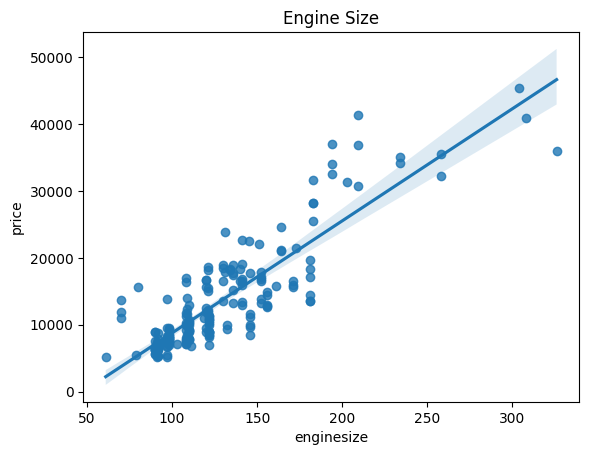

In [136]:
plt.title('Engine Size')
sns.regplot(x=data.enginesize, y=data.price)
plt.show()